```mermaid
flowchart LR
    %% Initial nodes

        A((Sender<br>b3f0))
        B((Sender<br>f02c))
        C((Sender<br>de6c))
        D((Receiver<br>d110))
        E((Sender<br>c998))
        
        %% Full interconnection among initial nodes
        A --> B
        A --> C
        A --> D
        B --> C
        B --> D
        C --> D
        A --> E
        E --> B
        E --> C
        E --> D


```
Fully Connected Topology with multiple senders and a receiver

C998 node was added later to the network

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.options.mode.chained_assignment = None  # default='warn'

In [12]:
nodes = ['b3f0', 'd110', 'de6c', 'f02c', 'c998']

for node in nodes:
    print(node)
    exec(f"{node} = pd.read_csv('./logs/logs4/{node}.log', sep = '>', header=None, names=['Timestamp', 'Message'])")

b3f0
d110
de6c
f02c
c998


In [13]:
b3f0['Id'] = "B3F0"
d110['Id'] = "D110"
de6c['Id'] = "DE6C"
f02c['Id'] = "F02C"
c998['Id'] = "C998"

Before Addition of C998

In [14]:
df = pd.concat([b3f0, d110, de6c, f02c], ignore_index=True)
df

,Timestamp,Message,Id
0,16:54:48.043,[ 25830][V][LoraMesher.cpp:378] receivingRout...,B3F0
1,16:54:48.054,[ 25841][V][LoraMesher.cpp:379] receivingRout...,B3F0
2,16:54:48.061,[ 25848][I][PacketService.cpp:12] createEmpty...,B3F0
3,16:54:48.070,[ 25857][I][LoraMesher.cpp:392] receivingRout...,B3F0
4,16:54:48.081,[ 25868][V][LoraMesher.cpp:647] processPacket...,B3F0
...,...,...,...
13467,17:12:30.782,[1088576][V][LoraMesher.cpp:455] waitBeforeSe...,F02C
13468,17:12:31.399,[1089193][V][LoraMesher.cpp:754] printHeaderP...,F02C
13469,17:12:31.503,[1089297][V][LoraMesher.cpp:575] sendPackets(...,F02C
13470,17:12:31.512,[1089306][I][PacketQueueService.h:80] deleteQ...,F02C


In [15]:
df.dropna(subset=['Message'], inplace=True)

In [16]:
# convert timestamp to timestamp dtype
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

C:\Users\tripa\AppData\Local\Temp\ipykernel_15556\1537839190.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])


In [17]:
df.reset_index(inplace=True, drop=True)

In [18]:
before_c998 = df.copy()
c998['Timestamp'] = pd.to_datetime(c998['Timestamp'])
before_c998 = before_c998[before_c998['Timestamp'] < c998['Timestamp'].min()]
before_c998

C:\Users\tripa\AppData\Local\Temp\ipykernel_15556\2742278553.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  c998['Timestamp'] = pd.to_datetime(c998['Timestamp'])


,Timestamp,Message,Id
0,2025-07-29 16:54:48.043,[ 25830][V][LoraMesher.cpp:378] receivingRout...,B3F0
1,2025-07-29 16:54:48.054,[ 25841][V][LoraMesher.cpp:379] receivingRout...,B3F0
2,2025-07-29 16:54:48.061,[ 25848][I][PacketService.cpp:12] createEmpty...,B3F0
3,2025-07-29 16:54:48.070,[ 25857][I][LoraMesher.cpp:392] receivingRout...,B3F0
4,2025-07-29 16:54:48.081,[ 25868][V][LoraMesher.cpp:647] processPacket...,B3F0
...,...,...,...
10824,2025-07-29 16:58:32.440,[250225][V][LoraMesher.cpp:455] waitBeforeSen...,F02C
10825,2025-07-29 16:58:33.022,[250807][V][LoraMesher.cpp:754] printHeaderPa...,F02C
10826,2025-07-29 16:58:33.119,[250904][V][LoraMesher.cpp:575] sendPackets()...,F02C
10827,2025-07-29 16:58:33.128,[250913][I][PacketQueueService.h:80] deleteQu...,F02C


Analyzing DataFrame:
Shape: (2375, 3)
Columns: ['Timestamp', 'Message', 'Id']
First few rows:


,Timestamp,Message,Id
0,2025-07-29 16:54:48.043,[ 25830][V][LoraMesher.cpp:378] receivingRout...,B3F0
1,2025-07-29 16:54:48.054,[ 25841][V][LoraMesher.cpp:379] receivingRout...,B3F0
2,2025-07-29 16:54:48.061,[ 25848][I][PacketService.cpp:12] createEmpty...,B3F0
3,2025-07-29 16:54:48.070,[ 25857][I][LoraMesher.cpp:392] receivingRout...,B3F0
4,2025-07-29 16:54:48.081,[ 25868][V][LoraMesher.cpp:647] processPacket...,B3F0


All Routing Packets Received: 
(23, 3)


,Timestamp,Message,Id
6,2025-07-29 16:54:48.103,[ 25890][I][RoutingTableService.cpp:77] proce...,B3F0
237,2025-07-29 16:56:31.644,[129430][I][RoutingTableService.cpp:77] proce...,B3F0
253,2025-07-29 16:56:33.026,[130812][I][RoutingTableService.cpp:77] proce...,B3F0
283,2025-07-29 16:56:49.168,[146954][I][RoutingTableService.cpp:77] proce...,B3F0
525,2025-07-29 16:58:32.074,[249859][I][RoutingTableService.cpp:77] proce...,B3F0


All Routing Packets Sent: 
(10, 3)


...

,Timestamp,Message,Id
15,2025-07-29 16:54:48.367,Send packet 1,B3F0
56,2025-07-29 16:55:08.460,Send packet 2,B3F0
97,2025-07-29 16:55:28.552,Send packet 3,B3F0
139,2025-07-29 16:55:48.644,Send packet 4,B3F0
168,2025-07-29 16:56:08.736,Send packet 5,B3F0


Final Messages Sent: 


,Timestamp,Message,Id,Type
0,2025-07-29 16:56:30.161,[127947][V][LoraMesher.cpp:598] sendHelloPack...,B3F0,Routing
1,2025-07-29 16:58:30.227,[248013][V][LoraMesher.cpp:598] sendHelloPack...,B3F0,Routing
2,2025-07-29 16:54:47.883,[ 7886][V][LoraMesher.cpp:598] sendHelloPack...,D110,Routing
3,2025-07-29 16:56:47.951,[127953][V][LoraMesher.cpp:598] sendHelloPack...,D110,Routing
4,2025-07-29 16:54:30.099,[ 7886][V][LoraMesher.cpp:598] sendHelloPack...,DE6C,Routing


Types per Node:


<Figure size 1000x600 with 0 Axes>

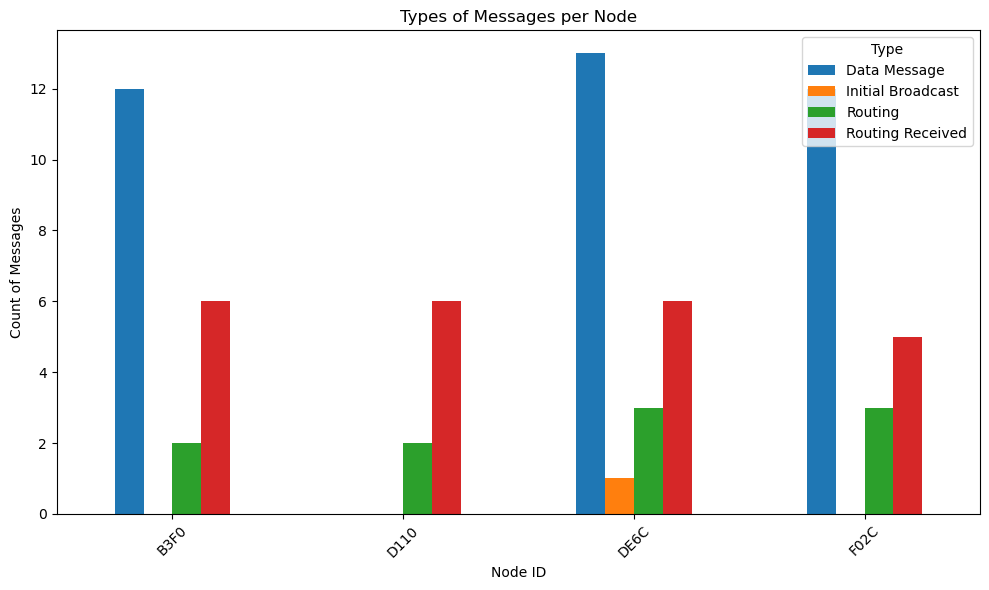

C:\Users\tripa\AppData\Local\Temp\ipykernel_15556\2451878669.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([time_diff[id].dt.total_seconds() for id in time_diff.keys()], labels=time_diff.keys())


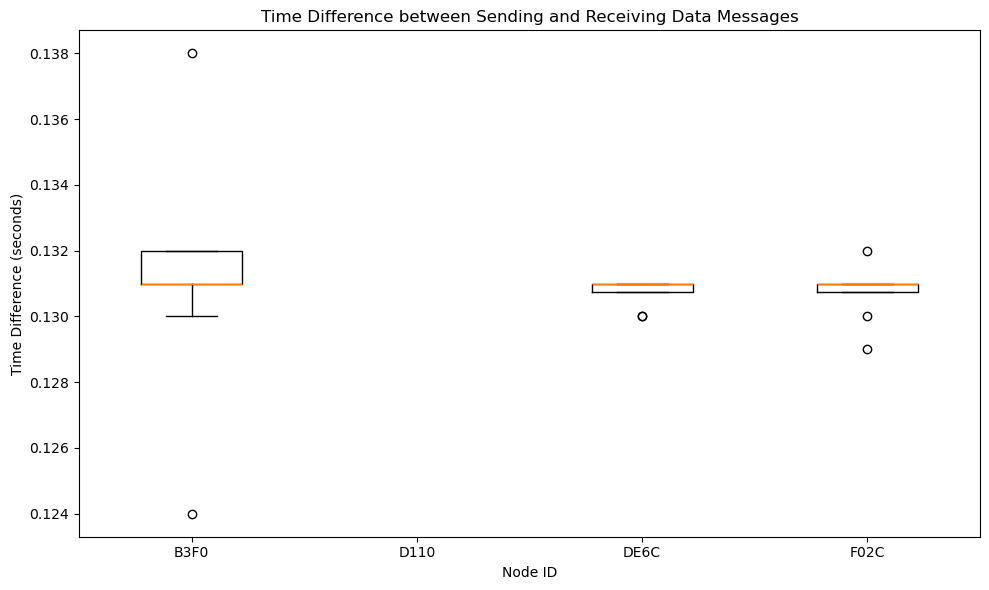

Packet Delivery Ratio (PDR):


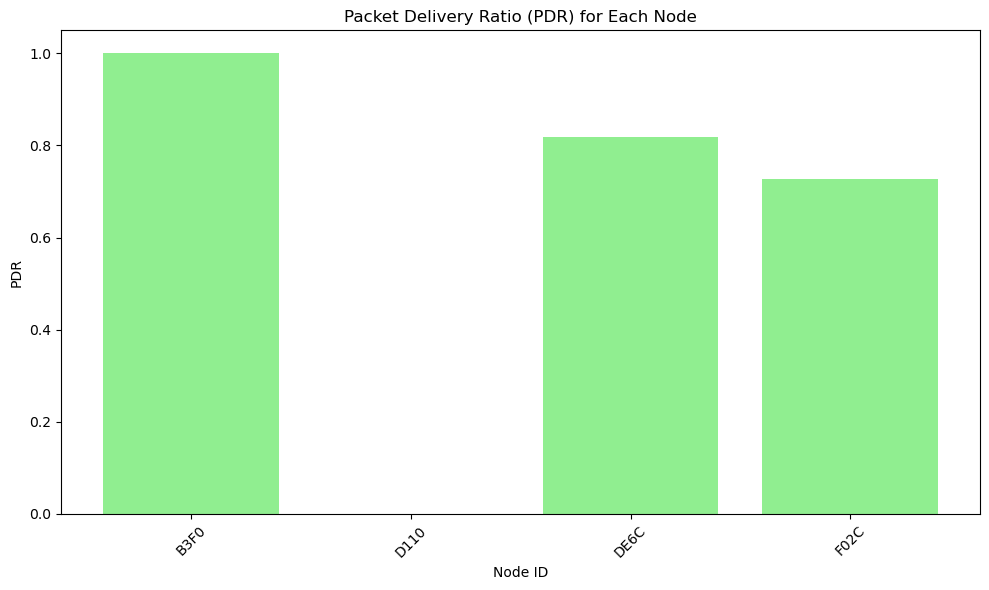

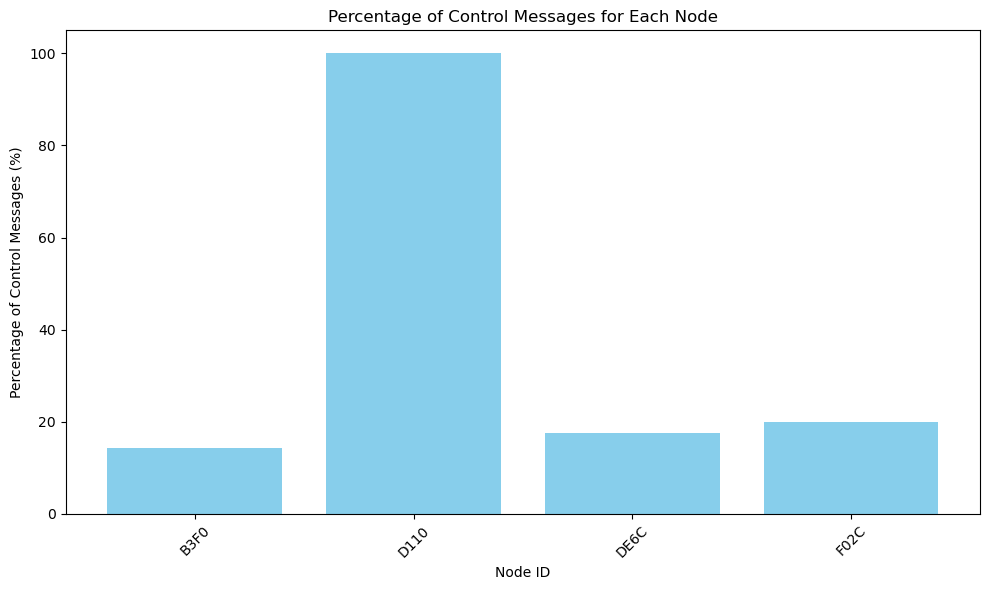

In [19]:
def analyze(df):
    print("Analyzing DataFrame:")
    print(f"Shape: {df.shape}")

    print(f"Columns: {df.columns.tolist()}")

    print("First few rows:")
    display(df.head())

    print("All Routing Packets Received: ")
    routing_df_rec = df[df['Message'].str.contains('Route packet from')]
    print(routing_df_rec.shape)
    display(routing_df_rec.head())

    print("All Routing Packets Sent: ")
    routing_df_send = df[df['Message'].str.contains('Creating Routing Packet')]
    print(routing_df_send.shape)
    display(routing_df_send.head())

    print("All Forwarding Packets: ")
    forward_df = df[df['Message'].str.contains('Forwarding it')]
    print(forward_df.shape)
    display(forward_df.head())

    print("Initial Broadcast Packets: ")
    initial_broadcast_df = df[df['Message'].str.contains('Sending packet to FFFF')]
    print(initial_broadcast_df.shape)
    display(initial_broadcast_df.head())

    print("Data Messages: ")
    data_msg_df = df[(df['Message'].str.contains('Send packet'))]
    print(data_msg_df.shape)
    display(data_msg_df.head())

    print("Final Messages Sent: ")
    routing_df_send['Type'] = "Routing"
    routing_df_rec['Type'] = "Routing Received"
    forward_df['Type'] = "Forwarding"
    initial_broadcast_df['Type'] = "Initial Broadcast"
    data_msg_df['Type'] = "Data Message"
    df_combined = pd.concat([routing_df_send, routing_df_rec, forward_df, initial_broadcast_df, data_msg_df], ignore_index=True)
    display(df_combined.head())

    print("Types per Node:")
    plt.figure(figsize=(10, 6))

    df_combined.groupby(['Id', 'Type']).size().unstack(fill_value=0).plot(kind='bar', figsize=(10, 6))
    plt.title('Types of Messages per Node')
    plt.xlabel('Node ID')
    plt.ylabel('Count of Messages')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    time_diff = {}
    pdr = {}
    for id in df['Id'].unique():
        msg_sent = df[(df['Id'] == id) & (df['Message'].str.contains(f'Src: {id} Dst: D110'))]
        msg_sent['MsgId'] = msg_sent['Message'].str.extract(r'Id: (\d+)')[0]
        msg_rec = df[(df['Id'] == 'D110') & (df['Message'].str.contains(f'Src: {id} Dst: D110'))] 
        msg_rec['MsgId'] = msg_rec['Message'].str.extract(r'Id: (\d+)')[0]
        pdr[id] = msg_rec.shape[0] / msg_sent.shape[0] if msg_sent.shape[0] > 0 else 0
        merged = pd.merge(msg_sent, msg_rec, on='MsgId', suffixes=('_send', '_rec'))
        time_diff[id] = (merged['Timestamp_rec'] - merged['Timestamp_send'])

    plt.figure(figsize=(10, 6))
    # box plot
    plt.boxplot([time_diff[id].dt.total_seconds() for id in time_diff.keys()], labels=time_diff.keys())
    plt.title('Time Difference between Sending and Receiving Data Messages')
    plt.xlabel('Node ID')
    plt.ylabel('Time Difference (seconds)')
    plt.tight_layout()
    plt.show()

    print("Packet Delivery Ratio (PDR):")
    plt.figure(figsize=(10, 6))
    plt.bar(pdr.keys(), pdr.values(), color='lightgreen')
    plt.title('Packet Delivery Ratio (PDR) for Each Node')
    plt.xlabel('Node ID')
    plt.ylabel('PDR')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # calculate percentage of control messages for each node
    control_messages = df_combined[df_combined['Type'].isin(['Routing'])]
    data_messages = df_combined[df_combined['Type'].isin(['Data Message', 'Forwarding', 'Initial Broadcast'])]

    control_percentage = {}

    for id in df_combined['Id'].unique():
        control_count = control_messages[control_messages['Id'] == id].shape[0]
        data_count = data_messages[data_messages['Id'] == id].shape[0]
        total_count = control_count + data_count
        if total_count > 0:
            percentage_control = (control_count / total_count) * 100
        else:
            percentage_control = 0
        control_percentage[id] = percentage_control
        
    # Plotting the control message percentage
    plt.figure(figsize=(10, 6))
    plt.bar(control_percentage.keys(), control_percentage.values(), color='skyblue')
    plt.title('Percentage of Control Messages for Each Node')
    plt.xlabel('Node ID')
    plt.ylabel('Percentage of Control Messages (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



    
analyze(before_c998)


Analyzing DataFrame:
Shape: (13671, 3)
Columns: ['Timestamp', 'Message', 'Id']
First few rows:


,Timestamp,Message,Id
0,2025-07-29 16:58:43.943,[261729][V][LoraMesher.cpp:378] receivingRout...,B3F0
1,2025-07-29 16:58:43.953,[261739][V][LoraMesher.cpp:379] receivingRout...,B3F0
2,2025-07-29 16:58:43.960,[261746][I][PacketService.cpp:12] createEmpty...,B3F0
3,2025-07-29 16:58:43.970,[261755][I][LoraMesher.cpp:392] receivingRout...,B3F0
4,2025-07-29 16:58:43.980,[261766][V][LoraMesher.cpp:647] processPacket...,B3F0


All Routing Packets Received: 
(110, 3)


,Timestamp,Message,Id
23,2025-07-29 16:58:45.922,[263707][I][RoutingTableService.cpp:77] proce...,B3F0
41,2025-07-29 16:58:49.008,[266794][I][RoutingTableService.cpp:77] proce...,B3F0
331,2025-07-29 17:00:31.442,[369228][I][RoutingTableService.cpp:77] proce...,B3F0
357,2025-07-29 17:00:33.712,[371498][I][RoutingTableService.cpp:77] proce...,B3F0
392,2025-07-29 17:00:46.445,[384232][I][RoutingTableService.cpp:77] proce...,B3F0


All Routing Packets Sent: 
(34, 3)


...

,Timestamp,Message,Id
52,2025-07-29 16:58:49.475,Send packet 13,B3F0
81,2025-07-29 16:59:09.568,Send packet 14,B3F0
124,2025-07-29 16:59:29.661,Send packet 15,B3F0
180,2025-07-29 16:59:49.754,Send packet 16,B3F0
237,2025-07-29 17:00:09.848,Send packet 17,B3F0


Final Messages Sent: 


,Timestamp,Message,Id,Type
0,2025-07-29 17:00:30.292,[368079][V][LoraMesher.cpp:598] sendHelloPack...,B3F0,Routing
1,2025-07-29 17:02:30.358,[488145][V][LoraMesher.cpp:598] sendHelloPack...,B3F0,Routing
2,2025-07-29 17:04:30.422,[608211][V][LoraMesher.cpp:598] sendHelloPack...,B3F0,Routing
3,2025-07-29 17:06:30.487,[728277][V][LoraMesher.cpp:598] sendHelloPack...,B3F0,Routing
4,2025-07-29 17:08:30.551,[848343][V][LoraMesher.cpp:598] sendHelloPack...,B3F0,Routing


Types per Node:


<Figure size 1000x600 with 0 Axes>

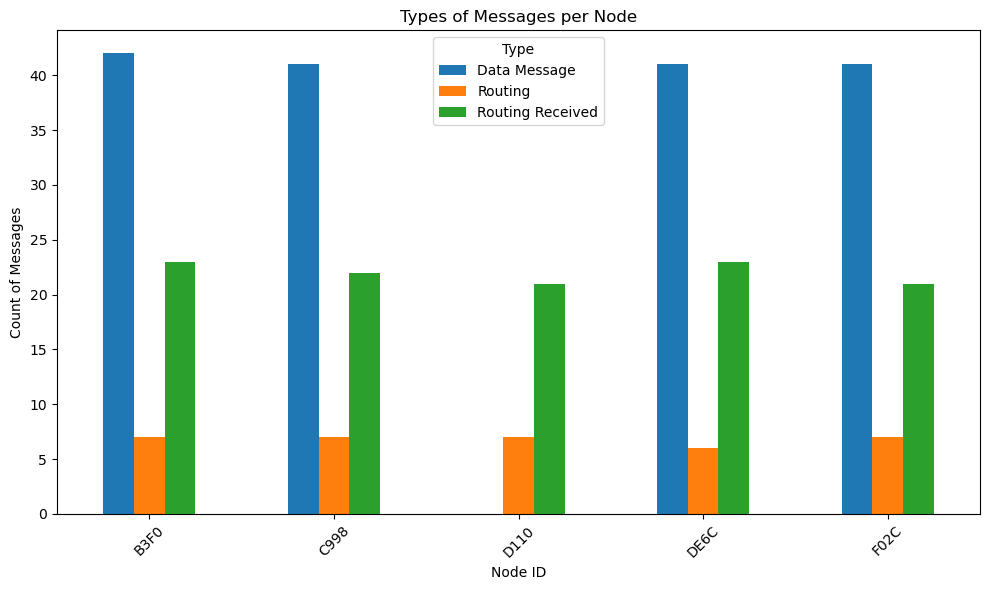

C:\Users\tripa\AppData\Local\Temp\ipykernel_15556\2451878669.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([time_diff[id].dt.total_seconds() for id in time_diff.keys()], labels=time_diff.keys())


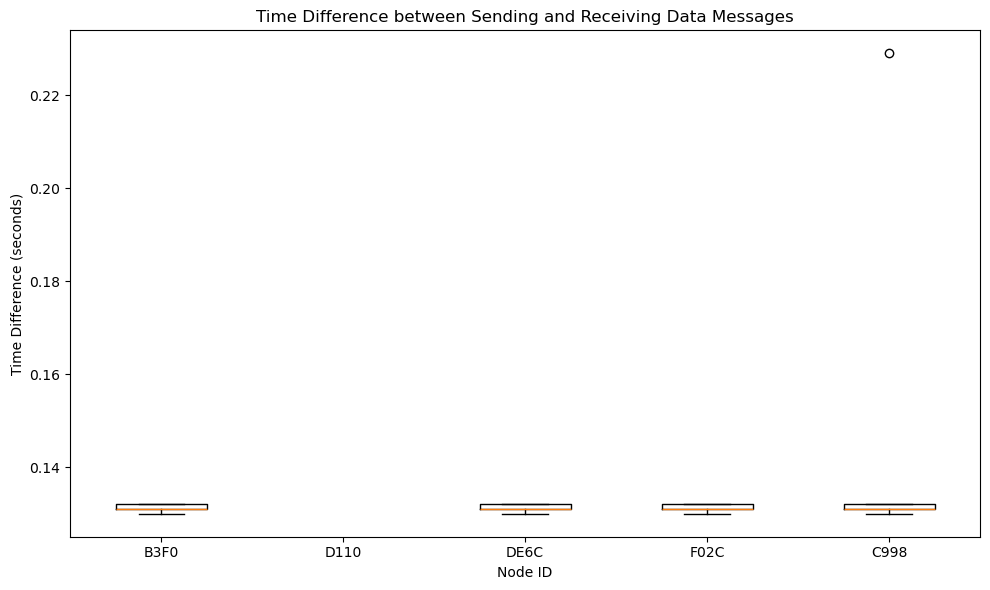

Packet Delivery Ratio (PDR):


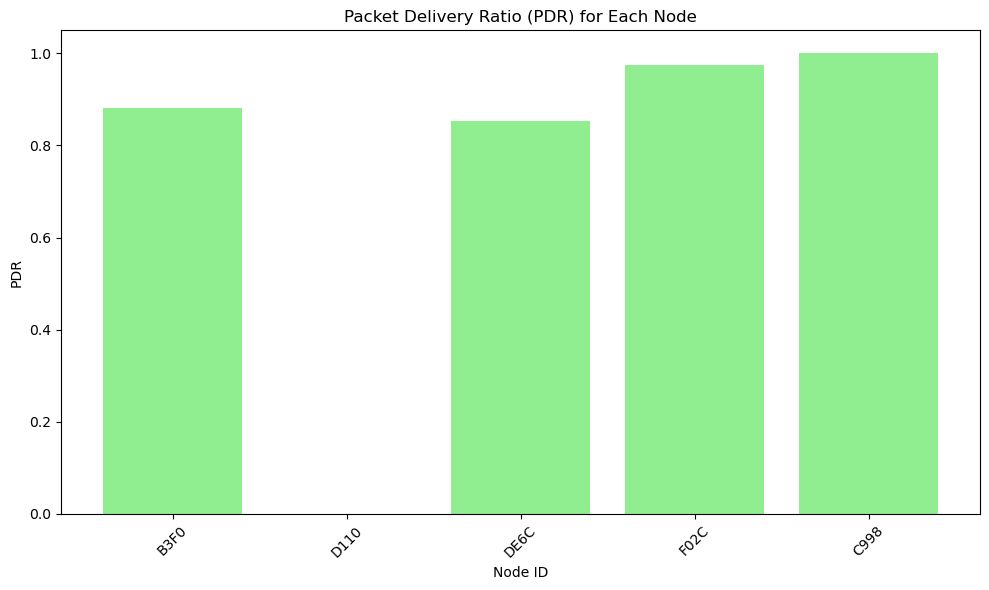

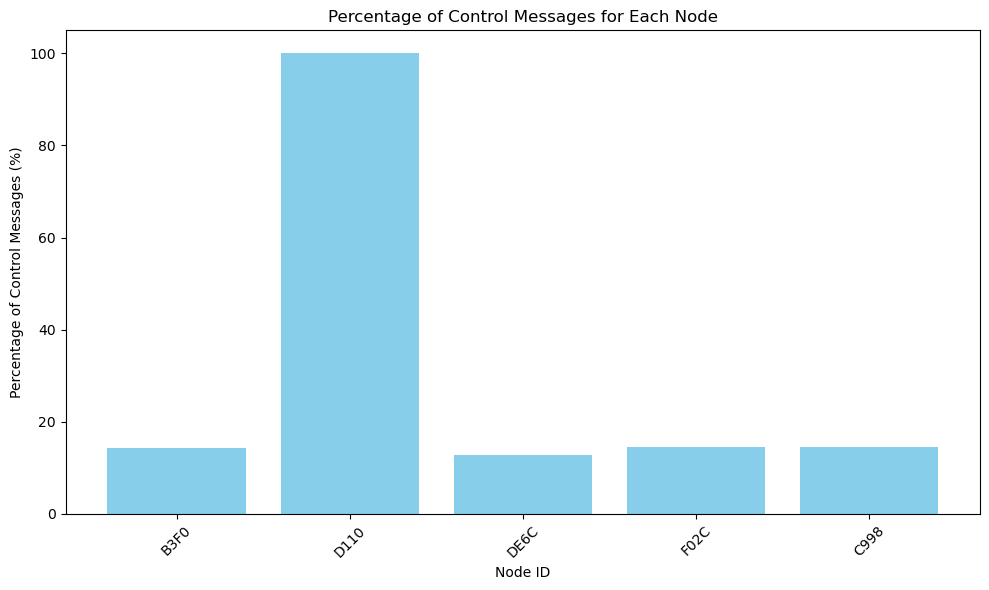

In [20]:
after_c998 = df.copy()
after_c998 = after_c998[after_c998['Timestamp'] >= c998['Timestamp'].min()]
after_c998 = pd.concat([after_c998, c998], ignore_index=True)
analyze(after_c998)